# Code-Mixed Marathi-English Sentiment Detection
## XLM-RoBERTa + CNN
**Dataset:** 1500 Marathi-English tweets  
**Labels:** -1 → Negative | 0 → Neutral | 1 → Positive  

**Why XLM-R?** A CNN with random embeddings cannot learn Marathi script from scratch on 1500 samples — it always collapses to predicting one class. XLM-RoBERTa is already pretrained on 100 languages including Marathi, so it understands the text from the start.

## Step 1: Install Libraries

In [1]:
!pip install transformers scikit-learn pandas numpy matplotlib seaborn torch openpyxl -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
print('PyTorch:', torch.__version__)

Device : cuda
PyTorch: 2.10.0+cu128


## Step 2: Upload & Load Dataset

In [5]:
from google.colab import files
uploaded = files.upload()   # Upload the .xlsx file

Saving Marathi__english_very_less__dataset_for_DM_Proj.xlsx to Marathi__english_very_less__dataset_for_DM_Proj.xlsx


In [6]:
df = pd.read_excel('Marathi__english_very_less__dataset_for_DM_Proj.xlsx')
df = df.dropna().reset_index(drop=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('Original label distribution:')
print(df['label'].value_counts())
df.head()

Shape: (1500, 2)
Columns: ['tweet', 'label']

Original label distribution:
label
 1    500
 0    500
-1    500
Name: count, dtype: int64


,tweet,label
0,कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...,1
1,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...,1
2,"पुणे येथील ""क्रांती ज्योती"" या कार्यक्रमात ज...",0
3,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...,1
4,महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...,1


## Step 3: Relabel -1, 0, 1 → negative, neutral, positive

In [7]:
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
df['sentiment'] = df['label'].map(label_map)

print('Relabeled distribution:')
print(df['sentiment'].value_counts())
print()
print(df[['tweet', 'label', 'sentiment']].head(6))

Relabeled distribution:
sentiment
positive    500
neutral     500
negative    500
Name: count, dtype: int64

                                               tweet  label sentiment
0    कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...      1  positive
1    पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...      1  positive
2    पुणे येथील "क्रांती ज्योती" या कार्यक्रमात ज...      0   neutral
3    आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...      1  positive
4    महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...      1  positive
5    अधुनिक भारताचे पहिले समाजक्रांतिकारक महात्मा...      1  positive


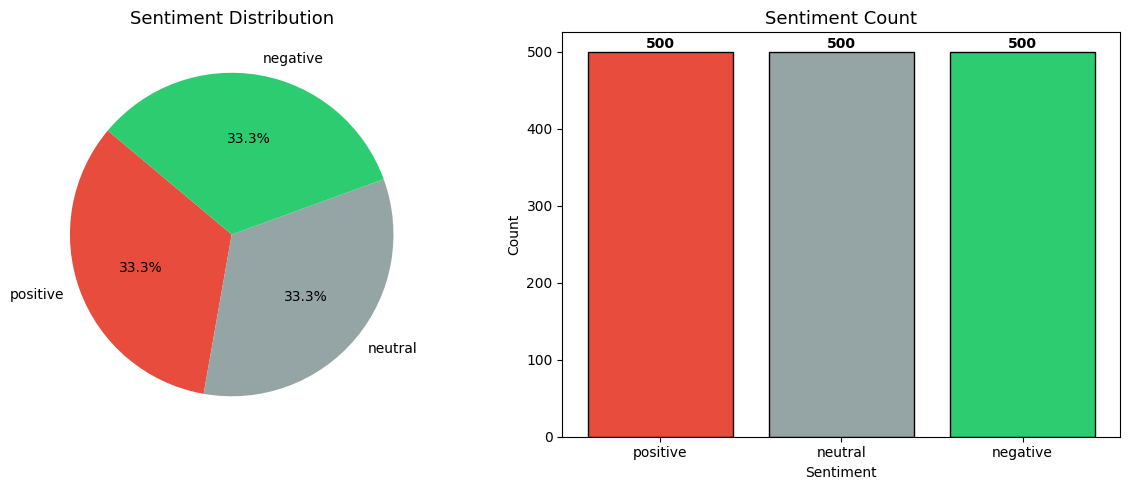

In [8]:
# Visualise
counts = df['sentiment'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title('Sentiment Distribution', fontsize=13)

bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[1].set_title('Sentiment Count', fontsize=13)
axes[1].set_xlabel('Sentiment'); axes[1].set_ylabel('Count')
for bar, c in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

## Step 4: Light Text Cleaning
We keep the Marathi text mostly intact — XLM-R handles it natively.

In [9]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)           # remove handles/hashtags
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['tweet'].apply(clean_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print('Samples after cleaning:', len(df))

Samples after cleaning: 1500


## Step 5: Encode Labels & Split

In [10]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['sentiment'])

NUM_CLASSES = len(le.classes_)
print('Classes    :', le.classes_)
print('Num classes:', NUM_CLASSES)
print()
for i, c in enumerate(le.classes_):
    print(f'  {i}  →  {c}')

Classes    : ['negative' 'neutral' 'positive']
Num classes: 3

  0  →  negative
  1  →  neutral
  2  →  positive


In [11]:
X = df['clean_text'].values
y = df['label_enc'].values

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 1050
Val   : 225
Test  : 225


## Step 6: Load XLM-RoBERTa Tokenizer

In [12]:
MODEL_NAME  = 'xlm-roberta-base'
MAX_LEN     = 128
BATCH_SIZE  = 16

xlm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded:', MODEL_NAME)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: xlm-roberta-base


## Step 7: PyTorch Dataset & DataLoaders

In [13]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_ds = SentimentDataset(X_train, y_train, xlm_tokenizer, MAX_LEN)
val_ds   = SentimentDataset(X_val,   y_val,   xlm_tokenizer, MAX_LEN)
test_ds  = SentimentDataset(X_test,  y_test,  xlm_tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('DataLoaders ready.')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

DataLoaders ready.
Train batches: 66 | Val: 15 | Test: 15


## Step 8: XLM-R + CNN Model

```
Input text (Marathi / English / code-mixed)
        │
  XLM-RoBERTa backbone
  (pretrained on 100 languages)
        │
  Token embeddings  (batch × 128 × 768)
        │
  ┌─────┬─────┬─────┐
  k=2   k=3   k=4     ← parallel Conv1D branches
  BN    BN    BN
  MaxPool MaxPool MaxPool
  └─────┴─────┴─────┘
        │
     Concat
        │
   Dense(256) → Dropout(0.4)
        │
   Dense(128) → Dropout(0.3)
        │
   Softmax(3)  → negative / neutral / positive
```

In [14]:
class XLMR_CNN_Sentiment(nn.Module):
    def __init__(self, model_name, num_classes,
                 num_filters=128, kernel_sizes=[2, 3, 4]):
        super().__init__()

        self.backbone   = AutoModel.from_pretrained(model_name)
        hidden_size     = self.backbone.config.hidden_size   # 768

        # Parallel CNN branches
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_size, num_filters,
                          kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(num_filters),
                nn.ReLU()
            )
            for k in kernel_sizes
        ])

        total_filters = num_filters * len(kernel_sizes)   # 128 * 3 = 384

        self.dropout1 = nn.Dropout(0.4)
        self.fc1      = nn.Linear(total_filters, 256)
        self.bn_fc    = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc2      = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(0.3)
        self.output   = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        # XLM-R: (batch, seq_len, 768)
        out = self.backbone(input_ids=input_ids,
                            attention_mask=attention_mask)
        x = out.last_hidden_state          # (batch, 128, 768)
        x = x.permute(0, 2, 1)            # (batch, 768, 128)  for Conv1d

        pooled = []
        for conv in self.convs:
            c = conv(x)                                    # (batch, 128, seq)
            c = F.max_pool1d(c, c.size(2)).squeeze(2)     # (batch, 128)
            pooled.append(c)

        x = torch.cat(pooled, dim=1)      # (batch, 384)
        x = self.dropout1(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout2(x)
        x = F.relu(self.fc2(x))
        x = self.dropout3(x)
        return self.output(x)             # logits (batch, 3)


model = XLMR_CNN_Sentiment(MODEL_NAME, NUM_CLASSES).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'Model ready on {DEVICE}')
print(f'Total parameters: {total:,}')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready on cuda
Total parameters: 279,061,891


## Step 9: Training — Two-Phase Strategy

| Phase | Epochs | What trains | Learning rate |
|-------|--------|-------------|---------------|
| 1 | 1–3 | CNN head only (backbone frozen) | 1e-3 |
| 2 | 4+ | Full model (backbone unfrozen) | 2e-5 |

In [15]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def freeze_backbone(m):
    for p in m.backbone.parameters():
        p.requires_grad = False
    print('Backbone FROZEN — training CNN head only.')


def unfreeze_backbone(m):
    for p in m.backbone.parameters():
        p.requires_grad = True
    print('Backbone UNFROZEN — fine-tuning full model.')


def get_optimizer(m, lr):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=lr, weight_decay=1e-2
    )


def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['label'].to(DEVICE)

            logits = model(ids, mask)
            loss   = criterion(logits, lbls)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)

    return total_loss / len(loader), correct / total


print('Training functions ready.')

Training functions ready.


In [16]:
PHASE1_EPOCHS = 3
PHASE2_EPOCHS = 12
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS
PATIENCE      = 5

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc     = 0.0
best_state       = None
patience_counter = 0

# Phase 1 — freeze backbone
freeze_backbone(model)
optimizer = get_optimizer(model, lr=1e-3)

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == PHASE1_EPOCHS + 1:
        unfreeze_backbone(model)
        optimizer = get_optimizer(model, lr=2e-5)

    phase = 'Head only' if epoch <= PHASE1_EPOCHS else 'Full model'

    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d}/{TOTAL_EPOCHS} [{phase}]  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f'  ✓ Best val_acc: {best_val_acc:.4f} — model saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE and epoch > PHASE1_EPOCHS:
            print('Early stopping.')
            break

model.load_state_dict(best_state)
print(f'\nDone. Best Val Accuracy: {best_val_acc:.4f}')

Backbone FROZEN — training CNN head only.
Epoch 01/15 [Head only]  Train Loss: 1.0952  Train Acc: 0.3867  Val Loss: 1.1057  Val Acc: 0.3333
  ✓ Best val_acc: 0.3333 — model saved
Epoch 02/15 [Head only]  Train Loss: 1.0356  Train Acc: 0.4781  Val Loss: 1.0299  Val Acc: 0.4844
  ✓ Best val_acc: 0.4844 — model saved
Epoch 03/15 [Head only]  Train Loss: 0.9514  Train Acc: 0.5581  Val Loss: 1.0588  Val Acc: 0.4267
Backbone UNFROZEN — fine-tuning full model.
Epoch 04/15 [Full model]  Train Loss: 0.7587  Train Acc: 0.7333  Val Loss: 0.7021  Val Acc: 0.7778
  ✓ Best val_acc: 0.7778 — model saved
Epoch 05/15 [Full model]  Train Loss: 0.6331  Train Acc: 0.8152  Val Loss: 0.7100  Val Acc: 0.8000
  ✓ Best val_acc: 0.8000 — model saved
Epoch 06/15 [Full model]  Train Loss: 0.5376  Train Acc: 0.8724  Val Loss: 0.7064  Val Acc: 0.7822
Epoch 07/15 [Full model]  Train Loss: 0.5215  Train Acc: 0.8971  Val Loss: 0.7088  Val Acc: 0.8000
Epoch 08/15 [Full model]  Train Loss: 0.4599  Train Acc: 0.9276  Val

## Step 10: Training Curves

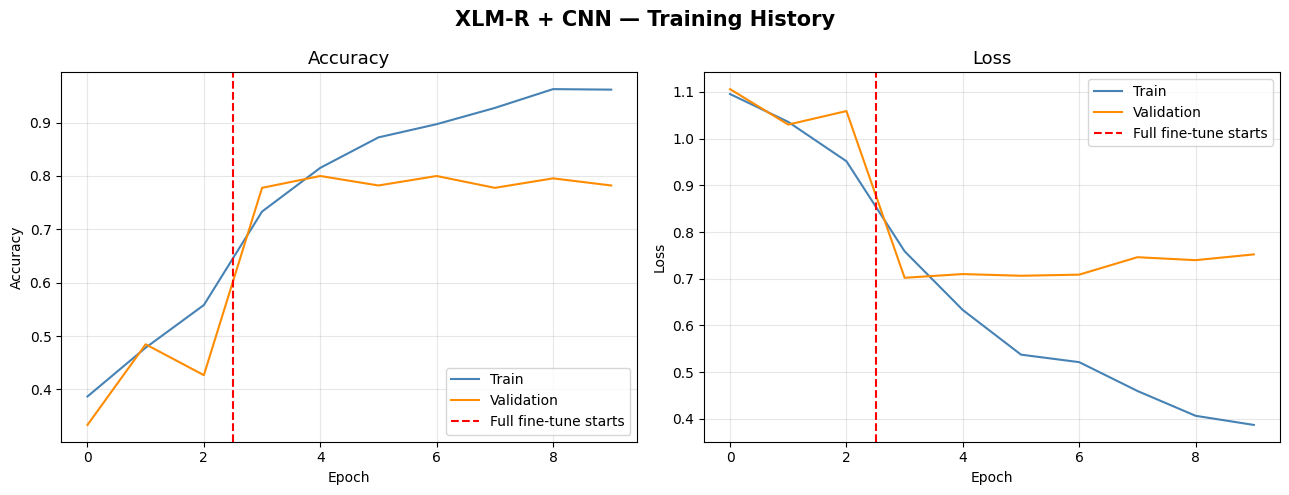

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history['train_acc'], label='Train',      color='steelblue')
axes[0].plot(history['val_acc'],   label='Validation', color='darkorange')
axes[0].axvline(PHASE1_EPOCHS - 0.5, color='red',
                linestyle='--', label='Full fine-tune starts')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train',      color='steelblue')
axes[1].plot(history['val_loss'],   label='Validation', color='darkorange')
axes[1].axvline(PHASE1_EPOCHS - 0.5, color='red',
                linestyle='--', label='Full fine-tune starts')
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('XLM-R + CNN — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 11: Evaluate on Test Set

In [18]:
test_loss, test_acc = run_epoch(model, test_loader, train=False)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 0.6231
Test Accuracy : 0.8044  (80.44%)


In [19]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model(ids, mask)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('Classification Report')
print('=' * 55)
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Classification Report
              precision    recall  f1-score   support

    negative       0.77      0.88      0.82        75
     neutral       0.81      0.76      0.79        75
    positive       0.84      0.77      0.81        75

    accuracy                           0.80       225
   macro avg       0.81      0.80      0.80       225
weighted avg       0.81      0.80      0.80       225



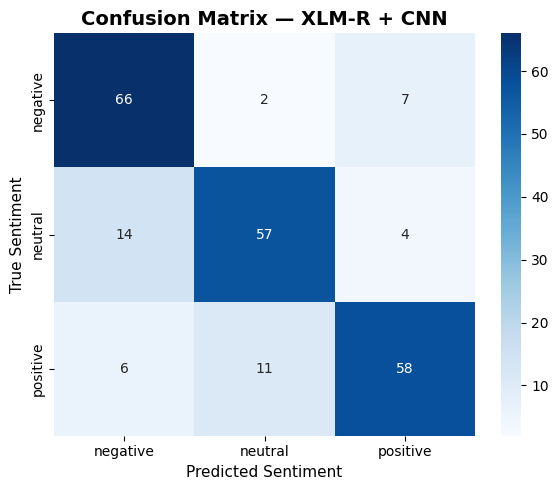

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — XLM-R + CNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sentiment', fontsize=11)
plt.ylabel('True Sentiment', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 12: Predict on New Text

In [21]:
def predict_sentiment(text):
    model.eval()
    cleaned = clean_text(text)
    enc = xlm_tokenizer(
        cleaned,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    idx   = np.argmax(probs)
    label = le.classes_[idx]
    conf  = probs[idx]

    display = text[:80] + '...' if len(text) > 80 else text
    print(f'Text       : {display}')
    print(f'Prediction : {label.upper()}  ({conf*100:.1f}% confidence)')
    print('Probabilities:')
    for lbl, p in zip(le.classes_, probs):
        bar = '█' * int(p * 30)
        print(f'  {lbl:10s} {p:.4f}  {bar}')
    print()
    return label


# Sample predictions
samples = [
    "मोदीजींनी खूप चांगले काम केले आहे. Great initiative!",
    "हे सरकार काहीच करत नाही. खूप वाईट परिस्थिती आहे.",
    "आज पुण्यात विधानसभेचे अधिवेशन होणार आहे.",
    "Wishing everyone a very happy and prosperous new year!",
    "This policy is completely wrong and harmful to the people."
]

for s in samples:
    predict_sentiment(s)

Text       : मोदीजींनी खूप चांगले काम केले आहे. Great initiative!
Prediction : POSITIVE  (53.2% confidence)
Probabilities:
  negative   0.1795  █████
  neutral    0.2888  ████████
  positive   0.5316  ███████████████

Text       : हे सरकार काहीच करत नाही. खूप वाईट परिस्थिती आहे.
Prediction : NEGATIVE  (91.1% confidence)
Probabilities:
  negative   0.9110  ███████████████████████████
  neutral    0.0512  █
  positive   0.0378  █

Text       : आज पुण्यात विधानसभेचे अधिवेशन होणार आहे.
Prediction : NEUTRAL  (78.1% confidence)
Probabilities:
  negative   0.0841  ██
  neutral    0.7808  ███████████████████████
  positive   0.1351  ████

Text       : Wishing everyone a very happy and prosperous new year!
Prediction : POSITIVE  (77.3% confidence)
Probabilities:
  negative   0.0494  █
  neutral    0.1780  █████
  positive   0.7726  ███████████████████████

Text       : This policy is completely wrong and harmful to the people.
Prediction : NEGATIVE  (78.5% confidence)
Probabilities:
  negative 

In [22]:
# Interactive prediction
print('Enter Marathi/English text. Type "quit" to stop.\n')
while True:
    user_input = input('Enter text: ')
    if user_input.lower() == 'quit':
        break
    if user_input.strip():
        predict_sentiment(user_input)
    else:
        print('Please enter some text.')

Enter Marathi/English text. Type "quit" to stop.

Enter text: I am very खुश
Text       : I am very खुश
Prediction : NEUTRAL  (58.3% confidence)
Probabilities:
  negative   0.1369  ████
  neutral    0.5826  █████████████████
  positive   0.2805  ████████

Enter text: निधी, वेदमूर्ती श्री देवव्रत यांच्या कार्यक्रमाला गेली होती
Text       : निधी, वेदमूर्ती श्री देवव्रत यांच्या कार्यक्रमाला गेली होती
Prediction : NEUTRAL  (76.2% confidence)
Probabilities:
  negative   0.0970  ██
  neutral    0.7619  ██████████████████████
  positive   0.1411  ████

Enter text: तरी माझ्या कडून पण नितीन सचिन चे हार्दिक अभिनंदन.
Text       : तरी माझ्या कडून पण नितीन सचिन चे हार्दिक अभिनंदन.
Prediction : POSITIVE  (94.0% confidence)
Probabilities:
  negative   0.0177  
  neutral    0.0419  █
  positive   0.9404  ████████████████████████████

Enter text: quit


## Step 13: Save the Model

In [23]:
torch.save(model.state_dict(), 'xlmr_cnn_sentiment.pt')
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved: xlmr_cnn_sentiment.pt')
print('Saved: label_encoder.pkl')

files.download('xlmr_cnn_sentiment.pt')
files.download('label_encoder.pkl')

Saved: xlmr_cnn_sentiment.pt
Saved: label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

| Component | Detail |
|---|---|
| Backbone | XLM-RoBERTa-base (pretrained on 100 languages) |
| CNN head | 3 parallel Conv1D branches (k=2,3,4) + MaxPool |
| Dense head | 256 → 128 → Softmax(3) |
| Optimizer | AdamW with weight decay |
| Loss | CrossEntropy + label smoothing 0.1 |
| Phase 1 | 3 epochs, backbone frozen, lr=1e-3 |
| Phase 2 | up to 12 epochs, full fine-tune, lr=2e-5 |
| Expected accuracy | 70–85% |